In [1]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def results_to_df(results_list, dataset, sampling_method, rec_method):
    res = []
    for config in results_list:
        if "e" in config.keys():
            e = config["e"]
        else:
            e = np.inf
        b = config["b"]
        test_mae = config["test_mae"]
        res.append((dataset, rec_method, sampling_method, e, b, test_mae))
    
    return pd.DataFrame.from_records(res, columns=["dataset", "recsys", "sampling", "e", "b", "test_mae"])

# RQ1: Does Meta Learning improve the accuracy-privacy trade-off? (MetaMF vs. NoMetaMF)

## absolute values

In [3]:
DATASET = "ml1m"
PATH = DATASET + "/"
with open(PATH + "MetaMF.baseline", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_df = results_to_df(meta_results, dataset="ml1m", sampling_method="baseline", rec_method="MetaMF")
with open(PATH + "NoMetaMF.baseline", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_df = results_to_df(nometa_results, dataset="ml1m", sampling_method="baseline", rec_method="NoMetaMF")
ml1m_results_df = pd.concat([meta_results_df, nometa_results_df]).reset_index(drop=True)
ml1m_results_df.head()

,dataset,recsys,sampling,e,b,test_mae
0,ml1m,MetaMF,baseline,inf,1,0.683778
1,ml1m,MetaMF,baseline,3.0,0,0.688107
2,ml1m,MetaMF,baseline,2.0,0,0.694842
3,ml1m,MetaMF,baseline,1.0,0,0.720614
4,ml1m,MetaMF,baseline,0.1,0,0.759160


In [4]:
DATASET = "bx"
PATH = DATASET + "/"
with open(PATH + "MetaMF.baseline", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_df = results_to_df(meta_results, dataset="bx", sampling_method="baseline", rec_method="MetaMF")
with open(PATH + "NoMetaMF.baseline", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_df = results_to_df(nometa_results, dataset="bx", sampling_method="baseline", rec_method="NoMetaMF")
bx_results_df = pd.concat([meta_results_df, nometa_results_df]).reset_index(drop=True)
bx_results_df.head()

,dataset,recsys,sampling,e,b,test_mae
0,bx,MetaMF,baseline,inf,1,1.183350
1,bx,MetaMF,baseline,3.0,0,1.185483
2,bx,MetaMF,baseline,2.0,0,1.212013
3,bx,MetaMF,baseline,1.0,0,1.477595
4,bx,MetaMF,baseline,0.1,0,2.116073


## relative change

Text(0, 0.5, '$\\Delta$MAE in $\\%$')

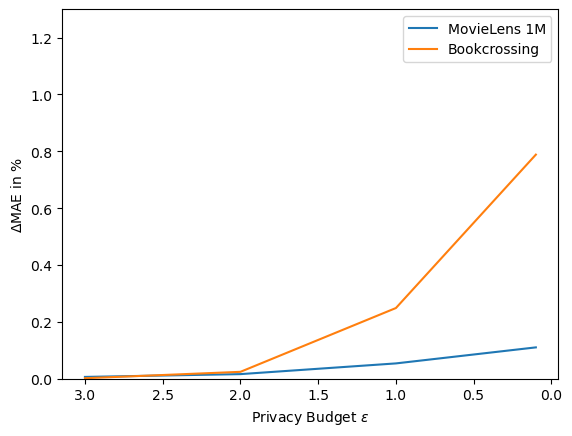

In [5]:
meta_nodp = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["b"] == 1)]["test_mae"].values
meta = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["b"] == 0)]
plt.plot(meta["e"], (meta["test_mae"] - meta_nodp) / meta_nodp, label="MovieLens 1M")

meta_nodp = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["b"] == 1)]["test_mae"].values
meta = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["b"] == 0)]
plt.plot(meta["e"], (meta["test_mae"] - meta_nodp) / meta_nodp, label="Bookcrossing")

#nometa_nodp = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["b"] == 1)]["test_mae"].values
#nometa = results_df[(results_df["recsys"] == "NoMetaMF") & (results_df["b"] == 0)]
#plt.plot(nometa["e"], (nometa["test_mae"] - nometa_nodp) / nometa_nodp, label="NoMetaMF")

plt.gca().invert_xaxis()
plt.ylim([0, 1.3])
plt.legend()
plt.xlabel(r"Privacy Budget $\varepsilon$")
plt.ylabel(r"$\Delta$MAE in $\%$")

Text(0, 0.5, '$\\Delta$MAE in $\\%$')

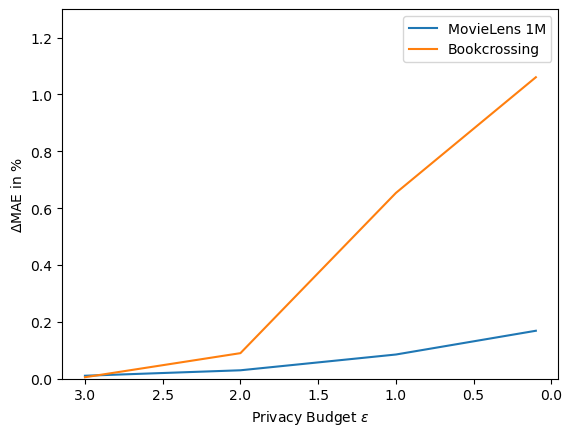

In [6]:
nometa_nodp = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["b"] == 1)]["test_mae"].values
nometa = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["b"] == 0)]
plt.plot(nometa["e"], (nometa["test_mae"] - nometa_nodp) / nometa_nodp, label="MovieLens 1M")

nometa_nodp = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["b"] == 1)]["test_mae"].values
nometa = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["b"] == 0)]
plt.plot(nometa["e"], (nometa["test_mae"] - nometa_nodp) / nometa_nodp, label="Bookcrossing")

plt.gca().invert_xaxis()
plt.ylim([0, 1.3])
plt.legend()
plt.xlabel(r"Privacy Budget $\varepsilon$")
plt.ylabel(r"$\Delta$MAE in $\%$")

# RQ2: How can sampling improve the trade-off further?

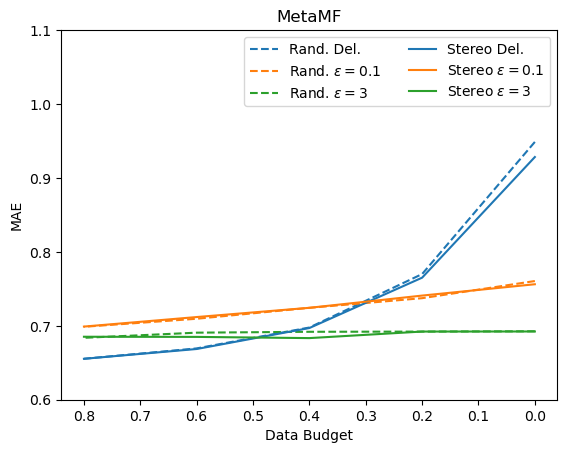

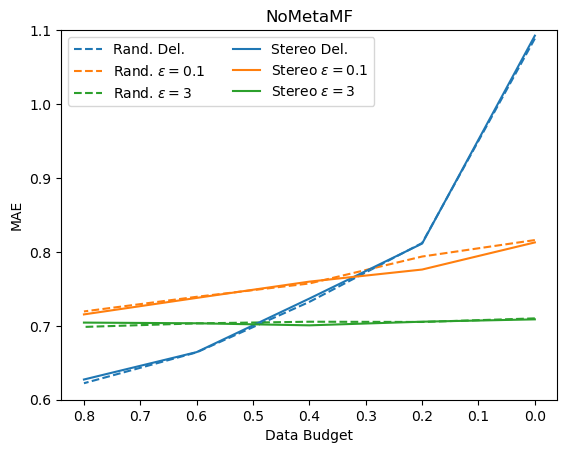

In [7]:
DATASET = "ml1m"
PATH = DATASET + "/"
with open(PATH + "MetaMF.random_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_random_dp_df = results_to_df(meta_results, dataset=DATASET, sampling_method="random_dp", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_random_dp_df = results_to_df(nometa_results, dataset=DATASET, sampling_method="random_dp", rec_method="NoMetaMF")
with open(PATH + "MetaMF.ister_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_ister_dp_df = results_to_df(meta_results, dataset=DATASET, sampling_method="ister_dp", rec_method="MetaMF")
with open(PATH + "NoMetaMF.ister_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_ister_dp_df = results_to_df(nometa_results, dataset=DATASET, sampling_method="ister_dp", rec_method="NoMetaMF")
dp_results_df = pd.concat([meta_results_random_dp_df, nometa_results_random_dp_df, meta_results_ister_dp_df, nometa_results_ister_dp_df]).reset_index(drop=True)

with open(PATH + "MetaMF.random_del", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_random_del_df = results_to_df(meta_results, dataset=DATASET, sampling_method="random_del", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_del", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_random_del_df = results_to_df(nometa_results, dataset=DATASET, sampling_method="random_del", rec_method="NoMetaMF")
with open(PATH + "MetaMF.ister_del", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_ister_del_df = results_to_df(meta_results, dataset=DATASET, sampling_method="ister_del", rec_method="MetaMF")
with open(PATH + "NoMetaMF.ister_del", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_ister_del_df = results_to_df(nometa_results, dataset=DATASET, sampling_method="ister_del", rec_method="NoMetaMF")
del_results_df = pd.concat([meta_results_random_del_df, nometa_results_random_del_df, meta_results_ister_del_df, nometa_results_ister_del_df]).reset_index(drop=True)

results_df = pd.concat([dp_results_df, del_results_df])
ml1m_results_df = results_df

deletion = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["sampling"] == "random_del")]
random01 = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["sampling"] == "random_dp") & (ml1m_results_df["e"] == 0.1)]
random3 = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["sampling"] == "random_dp") & (ml1m_results_df["e"] == 3)]
plt.plot(deletion["b"], deletion["test_mae"], label="Rand. Del.", c="C0", linestyle="dashed")
plt.plot(random01["b"], random01["test_mae"], label=r"Rand. $\epsilon=0.1$", c="C1", linestyle="dashed")
plt.plot(random3["b"], random3["test_mae"], label=r"Rand. $\epsilon=3$", c="C2", linestyle="dashed")

deletion = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["sampling"] == "ister_del")]
ister01 = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["sampling"] == "ister_dp") & (ml1m_results_df["e"] == 0.1)]
ister3 = ml1m_results_df[(ml1m_results_df["recsys"] == "MetaMF") & (ml1m_results_df["sampling"] == "ister_dp") & (ml1m_results_df["e"] == 3)]
plt.plot(deletion["b"], deletion["test_mae"], label="Stereo Del.", c="C0")
plt.plot(ister01["b"], ister01["test_mae"], label=r"Stereo $\epsilon=0.1$", c="C1")
plt.plot(ister3["b"], ister3["test_mae"], label=r"Stereo $\epsilon=3$", c="C2")

plt.gca().invert_xaxis()
plt.title("MetaMF")
plt.legend(ncol=2)
plt.ylabel("MAE")
plt.xlabel("Data Budget")
plt.ylim([0.6, 1.1])
plt.show()


plt.figure()
deletion = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["sampling"] == "random_del")]
random01 = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["sampling"] == "random_dp") & (ml1m_results_df["e"] == 0.1)]
random3 = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["sampling"] == "random_dp") & (ml1m_results_df["e"] == 3)]
plt.plot(deletion["b"], deletion["test_mae"], label="Rand. Del.", c="C0", linestyle="dashed")
plt.plot(random01["b"], random01["test_mae"], label=r"Rand. $\epsilon=0.1$", c="C1", linestyle="dashed")
plt.plot(random3["b"], random3["test_mae"], label=r"Rand. $\epsilon=3$", c="C2", linestyle="dashed")

deletion = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["sampling"] == "ister_del")]
ister01 = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["sampling"] == "ister_dp") & (ml1m_results_df["e"] == 0.1)]
ister3 = ml1m_results_df[(ml1m_results_df["recsys"] == "NoMetaMF") & (ml1m_results_df["sampling"] == "ister_dp") & (ml1m_results_df["e"] == 3)]
plt.plot(deletion["b"], deletion["test_mae"], label="Stereo Del.", c="C0")
plt.plot(ister01["b"], ister01["test_mae"], label=r"Stereo $\epsilon=0.1$", c="C1")
plt.plot(ister3["b"], ister3["test_mae"], label=r"Stereo $\epsilon=3$", c="C2")

plt.gca().invert_xaxis()
plt.title("NoMetaMF")
plt.legend(ncol=2)
plt.ylabel("MAE")
plt.xlabel("Data Budget")
plt.ylim([0.6, 1.1])
plt.show()



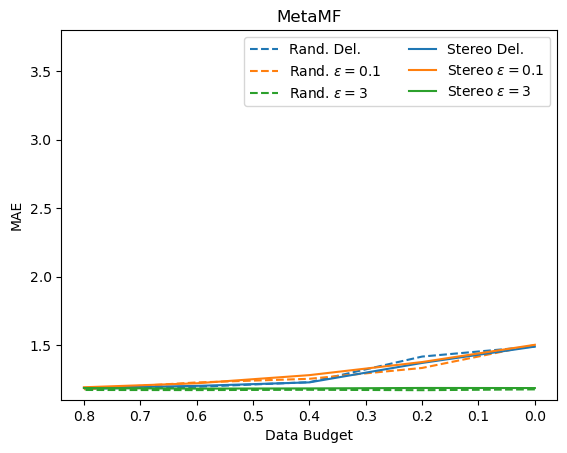

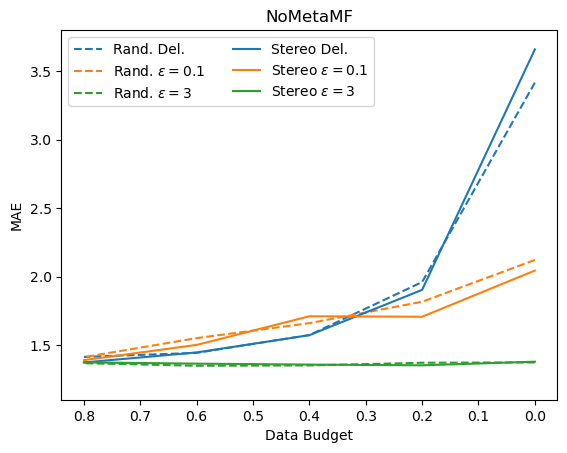

In [9]:
DATASET = "bx"
PATH = DATASET + "/"
with open(PATH + "MetaMF.random_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_random_dp_df = results_to_df(meta_results, dataset=DATASET, sampling_method="random_dp", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_random_dp_df = results_to_df(nometa_results, dataset=DATASET, sampling_method="random_dp", rec_method="NoMetaMF")

with open(PATH + "MetaMF.ister_dp", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_ister_dp_df = results_to_df(meta_results, dataset=DATASET, sampling_method="ister_dp", rec_method="MetaMF")
with open(PATH + "NoMetaMF.ister_dp", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_ister_dp_df = results_to_df(nometa_results, dataset=DATASET, sampling_method="ister_dp", rec_method="NoMetaMF")
dp_results_df = pd.concat([meta_results_random_dp_df, nometa_results_random_dp_df, meta_results_ister_dp_df, nometa_results_ister_dp_df]).reset_index(drop=True)

with open(PATH + "MetaMF.random_del", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_random_del_df = results_to_df(meta_results, dataset=DATASET, sampling_method="random_del", rec_method="MetaMF")
with open(PATH + "NoMetaMF.random_del", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_random_del_df = results_to_df(nometa_results, dataset=DATASET, sampling_method="random_del", rec_method="NoMetaMF")

with open(PATH + "MetaMF.ister_del", "rb") as f:
    meta_results = pkl.load(f)
    meta_results_ister_del_df = results_to_df(meta_results, dataset=DATASET, sampling_method="ister_del", rec_method="MetaMF")
with open(PATH + "NoMetaMF.ister_del", "rb") as f:
    nometa_results = pkl.load(f)
    nometa_results_ister_del_df = results_to_df(nometa_results, dataset=DATASET, sampling_method="ister_del", rec_method="NoMetaMF")
del_results_df = pd.concat([meta_results_random_del_df, nometa_results_random_del_df, meta_results_ister_del_df, nometa_results_ister_del_df]).reset_index(drop=True)

results_df = pd.concat([dp_results_df, del_results_df])
bx_results_df = results_df

deletion = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["sampling"] == "random_del")]
random01 = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["sampling"] == "random_dp") & (bx_results_df["e"] == 0.1)]
random3 = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["sampling"] == "random_dp") & (bx_results_df["e"] == 3)]
plt.plot(deletion["b"], deletion["test_mae"], label="Rand. Del.", c="C0", linestyle="dashed")
plt.plot(random01["b"], random01["test_mae"], label=r"Rand. $\epsilon=0.1$", c="C1", linestyle="dashed")
plt.plot(random3["b"], random3["test_mae"], label=r"Rand. $\epsilon=3$", c="C2", linestyle="dashed")

deletion = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["sampling"] == "ister_del")]
ister01 = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["sampling"] == "ister_dp") & (bx_results_df["e"] == 0.1)]
ister3 = bx_results_df[(bx_results_df["recsys"] == "MetaMF") & (bx_results_df["sampling"] == "ister_dp") & (bx_results_df["e"] == 3)]
plt.plot(deletion["b"], deletion["test_mae"], label="Stereo Del.", c="C0")
plt.plot(ister01["b"], ister01["test_mae"], label=r"Stereo $\epsilon=0.1$", c="C1")
plt.plot(ister3["b"], ister3["test_mae"], label=r"Stereo $\epsilon=3$", c="C2")

plt.gca().invert_xaxis()
plt.title("MetaMF")
plt.legend(ncol=2)
plt.ylabel("MAE")
plt.xlabel("Data Budget")
plt.ylim([1.1, 3.8])
plt.show()


plt.figure()
deletion = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["sampling"] == "random_del")]
random01 = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["sampling"] == "random_dp") & (bx_results_df["e"] == 0.1)]
random3 = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["sampling"] == "random_dp") & (bx_results_df["e"] == 3)]
plt.plot(deletion["b"], deletion["test_mae"], label="Rand. Del.", c="C0", linestyle="dashed")
plt.plot(random01["b"], random01["test_mae"], label=r"Rand. $\epsilon=0.1$", c="C1", linestyle="dashed")
plt.plot(random3["b"], random3["test_mae"], label=r"Rand. $\epsilon=3$", c="C2", linestyle="dashed")

deletion = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["sampling"] == "ister_del")]
ister01 = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["sampling"] == "ister_dp") & (bx_results_df["e"] == 0.1)]
ister3 = bx_results_df[(bx_results_df["recsys"] == "NoMetaMF") & (bx_results_df["sampling"] == "ister_dp") & (bx_results_df["e"] == 3)]
plt.plot(deletion["b"], deletion["test_mae"], label="Stereo Del.", c="C0")
plt.plot(ister01["b"], ister01["test_mae"], label=r"Stereo $\epsilon=0.1$", c="C1")
plt.plot(ister3["b"], ister3["test_mae"], label=r"Stereo $\epsilon=3$", c="C2")

plt.gca().invert_xaxis()
plt.title("NoMetaMF")
plt.legend(ncol=2)
plt.ylabel("MAE")
plt.xlabel("Data Budget")
plt.ylim([1.1, 3.8])
plt.show()
